# 03 — QSVM vs clássicos

QSVM com `ZZFeatureMap` + `FidelityQuantumKernel` (simulador ideal) no mesmo subset PCA 4D. Comparação lado a lado com os baselines do notebook 02.

In [1]:
from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay

ROOT = Path.cwd().resolve()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
    sys.path.insert(0, str(ROOT / "src"))

from qml_air_quality.config import load_config, project_root
from qml_air_quality.metrics import binary_metrics, metrics_table
from qml_air_quality.models import make_qsvc, predict_proba_positive

ROOT = project_root()
cfg = load_config()
SEED = cfg["project"]["random_seed"]
datasets = ROOT / cfg["paths"]["datasets_dir"]
kernels = ROOT / cfg["paths"]["kernels_dir"]
plots = ROOT / cfg["paths"]["plots_dir"]
kernels.mkdir(parents=True, exist_ok=True)
plots.mkdir(parents=True, exist_ok=True)

X_train = np.load(datasets / "X_train.npy")
X_test = np.load(datasets / "X_test.npy")
y_train = np.load(datasets / "y_train.npy")
y_test = np.load(datasets / "y_test.npy")
print("train/test", X_train.shape, X_test.shape)

train/test (500, 4) (200, 4)


## Treinar QSVC (cache de kernel opcional)

In [2]:
n_qubits = cfg["features"]["pca_components"]
qsvc, qkernel = make_qsvc(
    n_qubits=n_qubits,
    reps=cfg["quantum"]["repetitions"],
    entanglement=cfg["quantum"]["entanglement"],
    enforce_psd=cfg["quantum"]["enforce_psd"],
)

k_train_path = kernels / f"train_kernel_seed_{SEED}.npy"
k_test_path = kernels / f"test_kernel_seed_{SEED}.npy"
meta_path = kernels / f"kernel_metadata_seed_{SEED}.json"

t0 = time.perf_counter()
if cfg["quantum"]["cache_kernel"] and k_train_path.exists() and k_test_path.exists():
    print("Loading cached kernels…")
    K_train = np.load(k_train_path)
    K_test = np.load(k_test_path)
else:
    print("Evaluating quantum fidelity kernel (can take several minutes)…")
    K_train = qkernel.evaluate(x_vec=X_train)
    K_test = qkernel.evaluate(x_vec=X_test, y_vec=X_train)
    np.save(k_train_path, K_train)
    np.save(k_test_path, K_test)

kernel_seconds = time.perf_counter() - t0
print("kernel time (s):", round(kernel_seconds, 2))
print("K_train shape", K_train.shape, "symmetric", np.allclose(K_train, K_train.T, atol=1e-6))
print("diag ~1", np.allclose(np.diag(K_train), 1.0, atol=1e-4))

meta = {
    "feature_map": "ZZFeatureMap",
    "qubits": n_qubits,
    "repetitions": cfg["quantum"]["repetitions"],
    "entanglement": cfg["quantum"]["entanglement"],
    "train_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "seed": SEED,
    "kernel_seconds": kernel_seconds,
}
meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

Evaluating quantum fidelity kernel (can take several minutes)…


kernel time (s): 954.79
K_train shape (500, 500) symmetric True
diag ~1 False


198

In [3]:
from sklearn.svm import SVC

# Fit SVC on precomputed fidelity kernel (same protocol as QSVC)
clf = SVC(kernel="precomputed", class_weight="balanced", random_state=SEED)
t0 = time.perf_counter()
clf.fit(K_train, y_train)
train_s = time.perf_counter() - t0
t1 = time.perf_counter()
y_hat = clf.predict(K_test)
y_prob = predict_proba_positive(clf, K_test)
inf_s = time.perf_counter() - t1

q_row = binary_metrics(
    y_test,
    y_hat,
    y_prob,
    model_name="qsvm_fidelity",
    training_seconds=train_s,
    inference_seconds=inf_s,
)
q_row["kernel_seconds"] = kernel_seconds
print(q_row)

{'model': 'qsvm_fidelity', 'average_precision': 0.10597804086747978, 'balanced_accuracy': 0.4736632083000798, 'precision_extreme': 0.07894736842105263, 'recall_extreme': 0.14285714285714285, 'f1_extreme': 0.1016949152542373, 'mcc': -0.04116041281420537, 'auroc': 0.5038574088853418, 'training_seconds': 0.009106743999836908, 'inference_seconds': 0.00086509299944737, 'kernel_seconds': 954.7942033259997}


## Comparação final

,model,average_precision,balanced_accuracy,precision_extreme,recall_extreme,f1_extreme,mcc,auroc,training_seconds,inference_seconds,kernel_seconds
0,logistic,0.532967,0.820963,0.361702,0.809524,0.500000,0.464116,0.886140,0.002833,0.000241,NaN
1,svm_linear,0.532825,0.494413,0.000000,0.000000,0.000000,-0.034424,0.899707,0.026682,0.005998,NaN
2,svm_rbf,0.378001,0.500000,0.000000,0.000000,0.000000,0.000000,0.807396,0.019516,0.010455,NaN
3,qsvm_fidelity,0.105978,0.473663,0.078947,0.142857,0.101695,-0.041160,0.503857,0.009107,0.000865,954.794203
4,dummy,0.105000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.004756,0.000297,NaN


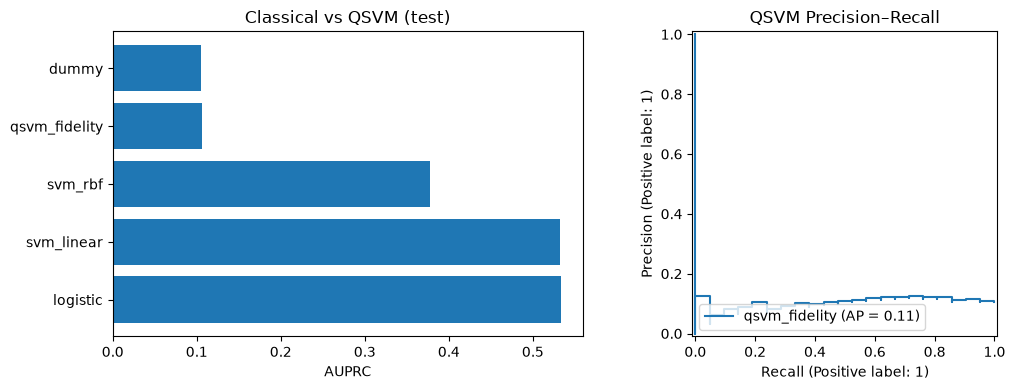

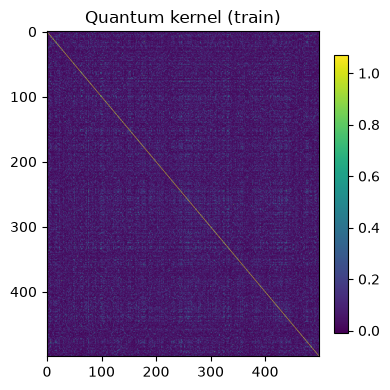

AUPRC QSVM=0.1060 | best classical=0.5330 | delta=-0.4270
Nota: resultado preliminar da PoC — não interpreta como vantagem quântica geral.


In [4]:
classical_path = datasets / "classical_metrics.csv"
if classical_path.exists():
    classical = pd.read_csv(classical_path)
else:
    classical = pd.DataFrame()

comparison = pd.concat([classical, pd.DataFrame([q_row])], ignore_index=True)
comparison = comparison.sort_values("average_precision", ascending=False).reset_index(drop=True)
display(comparison)
comparison.to_csv(datasets / "comparison_metrics.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(comparison["model"], comparison["average_precision"])
axes[0].set_xlabel("AUPRC")
axes[0].set_title("Classical vs QSVM (test)")
if y_prob is not None:
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name="qsvm_fidelity", ax=axes[1])
    if classical_path.exists():
        # reload classical probas by quick re-fit is heavy; just show QSVM PR here
        pass
    axes[1].set_title("QSVM Precision–Recall")
fig.tight_layout()
fig.savefig(plots / "comparison_auprc.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(K_train, cmap="viridis", aspect="auto")
ax.set_title("Quantum kernel (train)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(plots / "quantum_kernel_matrix.png", dpi=120)
plt.show()

best_classical = (
    classical.loc[classical["model"] != "dummy", "average_precision"].max()
    if len(classical)
    else float("nan")
)
delta = q_row["average_precision"] - best_classical
print(f"AUPRC QSVM={q_row['average_precision']:.4f} | best classical={best_classical:.4f} | delta={delta:.4f}")
print("Nota: resultado preliminar da PoC — não interpreta como vantagem quântica geral.")